# CPL Dark Energy Model

This notebook explores the Chevallier-Polarski-Linder (CPL) dark energy parameterisation:

$$w(a) = w_0 + w_a(1-a) = w_0 + w_a\frac{z}{1+z}$$

**Contents**
1. Basic evolution checks — $w(z)$, $\Omega_\mathrm{DE}(z)$, $E(z)$
2. Distance measures — $D_L(z)$, $\mu(z)$
3. Comparison with SNe Ia data (Pantheon 2018)

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import toolscosmo

plt.rcParams.update({'font.size': 13, 'lines.linewidth': 2.2})

## Helper

Always create a **fresh** `par` object per model — reusing the same object and mutating `w0`/`wa` triggered a caching bug (see [sambit-giri/toolscosmo#4](https://github.com/sambit-giri/toolscosmo/issues/4), fixed in `dark-energy-dev`).

In [155]:
def cpl_par(w0, wa):
    """Return a fresh CPL parameter object with the given (w0, wa)."""
    p = toolscosmo.par(DE='CPL')
    p.DE.w0 = w0
    p.DE.wa = wa
    return p

zs = 10**np.linspace(-3, np.log10(3), 300)  # z in [0.001, 3]

## 1. Equation of State $w(z)$

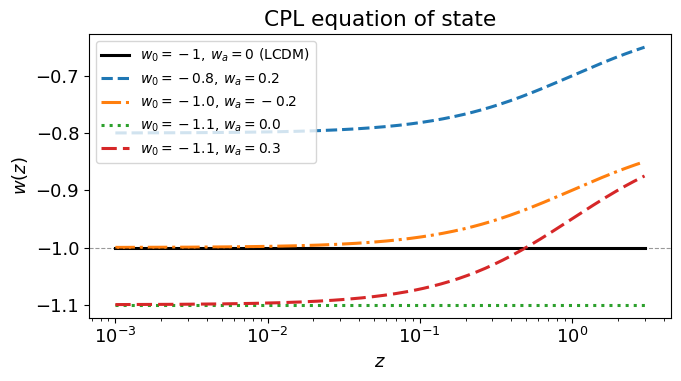

In [156]:
models = [
    (-1.0,  0.0, '$w_0{=}-1,\, w_a{=}0$ (LCDM)',      'k',  '-'),
    (-0.8,  0.2, '$w_0{=}-0.8,\, w_a{=}0.2$',         'C0', '--'),
    (-1.0, 0.2, '$w_0{=}-1.0,\, w_a{=}-0.2$',        'C1', '-.'),
    (-1.1,  0.0, '$w_0{=}-1.1,\, w_a{=}0.0$',         'C2', ':'),
    (-1.1,  0.3, '$w_0{=}-1.1,\, w_a{=}0.3$',   'C3', (0,(5,2))),
]

fig, ax = plt.subplots(figsize=(7, 4))
for w0, wa, label, color, ls in models:
    w = w0 + wa * zs / (1 + zs)
    ax.semilogx(zs, w, color=color, ls=ls, label=label)
ax.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('$z$')
ax.set_ylabel('$w(z)$')
ax.set_title('CPL equation of state')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 2. Dark Energy Density $\Omega_\mathrm{DE}(z)$

The correct evolution (derived from the continuity equation $\dot\rho = -3H(1+w)\rho$) is

$$\Omega_\mathrm{DE}(z) = \Omega_{\Lambda,0}\, a^{-3(1+w_0+w_a)}\, e^{-3w_a(1-a)}, \qquad a=\frac{1}{1+z}$$

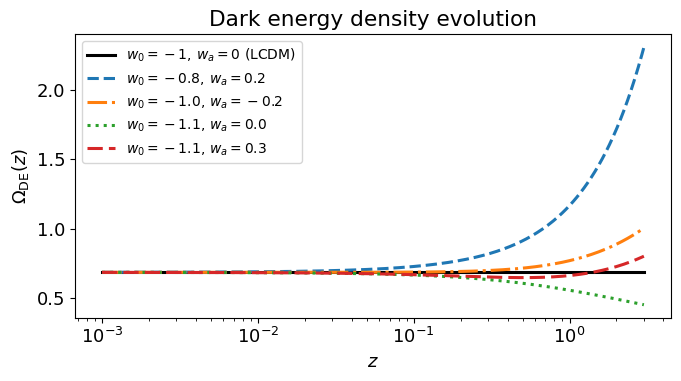

In [157]:
from toolscosmo.cosmo import Omega_DE

fig, ax = plt.subplots(figsize=(7, 4))
for w0, wa, label, color, ls in models:
    p = cpl_par(w0, wa)
    ODE = np.vectorize(lambda z: Omega_DE(z, p))(zs)
    ax.semilogx(zs, ODE, color=color, ls=ls, label=label)
ax.set_xlabel('$z$')
ax.set_ylabel('$\\Omega_\\mathrm{DE}(z)$')
ax.set_title('Dark energy density evolution')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 3. Normalised Hubble Parameter $E(z) = H(z)/H_0$

Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done


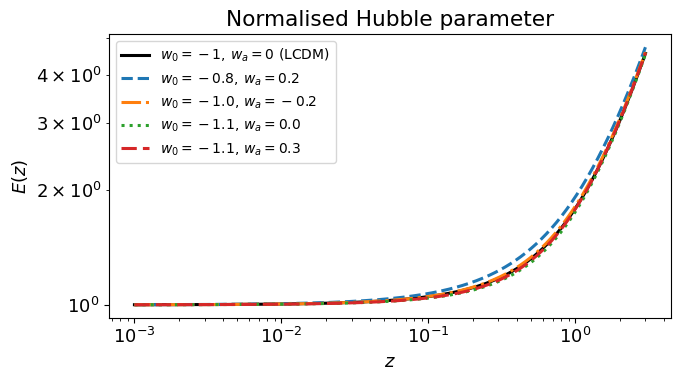

In [158]:
fig, ax = plt.subplots(figsize=(7, 4))
for w0, wa, label, color, ls in models:
    p = cpl_par(w0, wa)
    Ez = toolscosmo.Ez_model(p)(zs)
    ax.loglog(zs, Ez, color=color, ls=ls, label=label)
ax.set_xlabel('$z$')
ax.set_ylabel('$E(z)$')
ax.set_title('Normalised Hubble parameter')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4. Distance Modulus $\mu(z)$

$$\mu(z) = 5\log_{10}\!\left[\frac{D_L(z)}{10\,\text{pc}}\right]$$

Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done


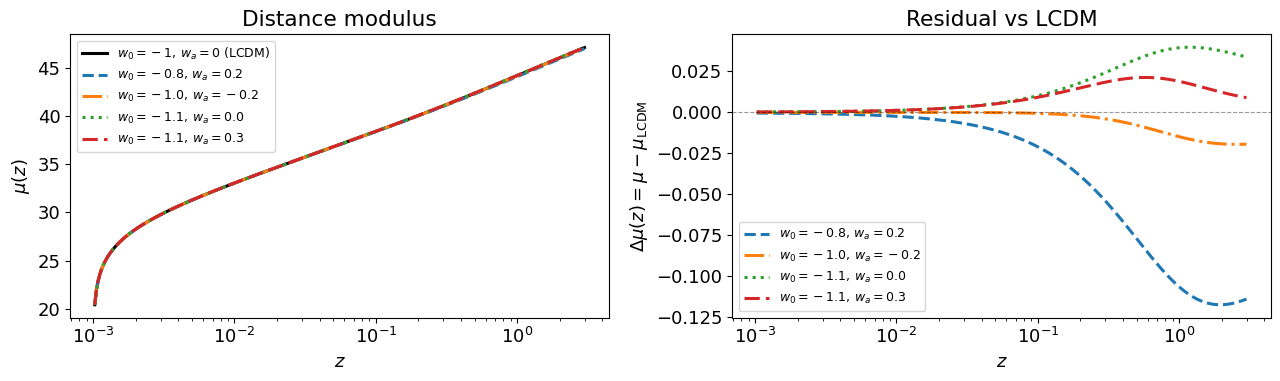

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

p_lcdm = cpl_par(-1.0, 0.0)
mu_lcdm = toolscosmo.distance_modulus(zs, p_lcdm)

ax = axes[0]
for w0, wa, label, color, ls in models:
    p = cpl_par(w0, wa)
    ax.semilogx(zs, toolscosmo.distance_modulus(zs, p), color=color, ls=ls, label=label)
ax.set_xlabel('$z$')
ax.set_ylabel('$\\mu(z)$')
ax.set_title('Distance modulus')
ax.legend(fontsize=9)

ax = axes[1]
for w0, wa, label, color, ls in models:
    if w0 == -1.0 and wa == 0.0:
        continue
    p = cpl_par(w0, wa)
    dmu = toolscosmo.distance_modulus(zs, p) - mu_lcdm
    ax.semilogx(zs, dmu, color=color, ls=ls, label=label)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('$z$')
ax.set_ylabel('$\\Delta\\mu(z) = \\mu - \\mu_\\mathrm{LCDM}$')
ax.set_title('Residual vs LCDM')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Comparison with SNe Ia Data (Pantheon 2018)

The Pantheon compilation (Scolnic et al. 2018) — 1048 SNe Ia with redshifts $0.01 < z < 2.3$ — is loaded via `toolscosmo.load_sne_data`, which downloads and caches the file on first use.

In [160]:
sne = toolscosmo.load_sne_data('pantheon')
print(f"Loaded {len(sne['z'])} SNe Ia")

Loaded 1048 SNe Ia


Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done


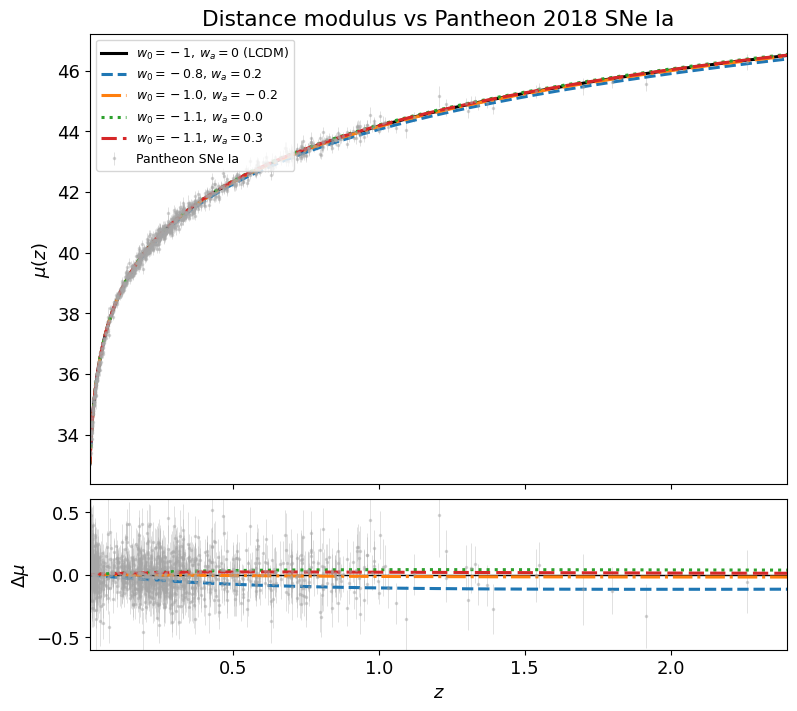

In [161]:
# mb is the corrected apparent B magnitude; mu = mb - M_B.
# We marginalise over M_B by calibrating each model to the data.
z_sne  = sne['z']
mb     = sne['mu']       # corrected apparent magnitude
dmb    = sne['mu_err']

p_ref  = cpl_par(-1.0, 0.0)
mu_ref = toolscosmo.distance_modulus(z_sne, p_ref)
M_eff  = np.average(mb - mu_ref, weights=1/dmb**2)
mu_obs = mb - M_eff

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

ax = axes[0]
ax.errorbar(z_sne, mu_obs, yerr=dmb, fmt='.', color='0.65',
            alpha=0.4, ms=3, elinewidth=0.6, label='Pantheon SNe Ia')
z_th = 10**np.linspace(np.log10(0.01), np.log10(2.4), 400)
for w0, wa, label, color, ls in models:
    p = cpl_par(w0, wa)
    ax.plot(z_th, toolscosmo.distance_modulus(z_th, p), color=color, ls=ls, label=label)
ax.set_ylabel('$\\mu(z)$')
ax.set_title('Distance modulus vs Pantheon 2018 SNe Ia')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0.01, 2.4)

ax = axes[1]
mu_lcdm_sne = toolscosmo.distance_modulus(z_sne, p_ref)
ax.errorbar(z_sne, mu_obs - mu_lcdm_sne, yerr=dmb, fmt='.', color='0.65',
            alpha=0.4, ms=3, elinewidth=0.6)
ax.axhline(0, color='k', lw=1)
for w0, wa, label, color, ls in models:
    if w0 == -1.0 and wa == 0.0:
        continue
    p = cpl_par(w0, wa)
    dmu = toolscosmo.distance_modulus(z_th, p) - toolscosmo.distance_modulus(z_th, p_ref)
    ax.plot(z_th, dmu, color=color, ls=ls)
ax.set_xlabel('$z$')
ax.set_ylabel('$\\Delta\\mu$')
ax.set_ylim(-0.6, 0.6)

plt.tight_layout()
plt.show()

## 6. Quick $\chi^2$ Summary

A rough goodness-of-fit for each CPL model vs the Pantheon data, ignoring off-diagonal covariances.

In [162]:
print(f"{'Model':<45} {'chi2/dof':>10}")
print('-' * 57)
ndof = len(z_sne) - 2
for w0, wa, label, color, ls in models:
    p = cpl_par(w0, wa)
    mu_model = toolscosmo.distance_modulus(z_sne, p)
    M_i  = np.average(mb - mu_model, weights=1/dmb**2)
    mu_i = mb - M_i
    chi2 = np.sum(((mu_i - mu_model) / dmb)**2)
    print(f'{label:<45} {chi2/ndof:>10.3f}')

Model                                           chi2/dof
---------------------------------------------------------
Preparing cosmological solvers...
...done
$w_0{=}-1,\, w_a{=}0$ (LCDM)                       1.009
Preparing cosmological solvers...
...done
$w_0{=}-0.8,\, w_a{=}0.2$                          1.022
Preparing cosmological solvers...
...done
$w_0{=}-1.0,\, w_a{=}-0.2$                         1.007
Preparing cosmological solvers...
...done
$w_0{=}-1.1,\, w_a{=}0.0$                          1.029
Preparing cosmological solvers...
...done
$w_0{=}-1.1,\, w_a{=}0.3$                          1.020


Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done
Preparing cosmological solvers...
...done


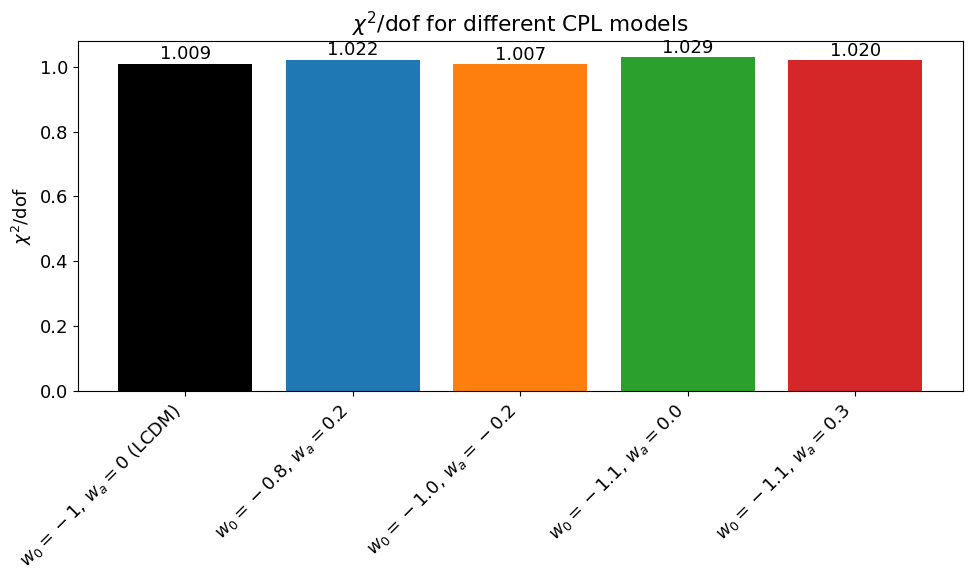

In [163]:
# Collect chi2/dof values
chi2_dof_values = []
labels = []
for w0, wa, label, color, ls in models:
    p = cpl_par(w0, wa)
    mu_model = toolscosmo.distance_modulus(z_sne, p)
    M_i  = np.average(mb - mu_model, weights=1/dmb**2)
    mu_i = mb - M_i
    chi2 = np.sum(((mu_i - mu_model) / dmb)**2)
    chi2_dof_values.append(chi2 / ndof)
    labels.append(label)

# Plot chi2/dof
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, chi2_dof_values, color=['k', 'C0', 'C1', 'C2', 'C3'])
ax.set_ylabel(r'$\chi^2 / \mathrm{dof}$')
ax.set_title(r'$\chi^2 / \mathrm{dof}$ for different CPL models')
ax.set_xticklabels(labels, rotation=45, ha='right')
for bar, val in zip(bars, chi2_dof_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## MCMC sampling

In [4]:
from astropy import units
try:
  import AstronomyCalc
except:
  !pip install git+https://github.com/sambit-giri/AstronomyCalc.git
  import AstronomyCalc

### Model

In [5]:
import toolscosmo as tcm

def model(param, zz):
    w0 = param

    p = tcm.par(DE='CPL')
    
    p.DE.w0 = w0
    #p.DE.wa = wa

   # p.cosmo.Om = Om0
    #p.cosmo.h = h0

    return tcm.distance_modulus(zz, p)

### Bringing Pantheon data 

In [8]:
# Pantheon data
sne = tcm.load_sne_data('pantheon')
print(f"Loaded {len(sne['z'])} SNe Ia datapoints")

z_sample = sne['z']
mu_sample = sne['mu']       
dmu_sample = sne['mu_err']

Loaded 1048 SNe Ia datapoints


### Sampling

In [12]:
import numpy as np
def log_likelihood(param):

    zz_obs = z_sample
    mu_obs = mu_sample
    covinv = np.eye(len(mu_sample)) * (1 / dmu_sample**2)

    mu_mod = model(param, zz_obs)   # model måste använda w0, wa

    delta = (mu_obs-mu_mod)
    logL = -0.5 * np.dot(delta.T, np.dot(covinv, delta))
    return logL

mins = np.array([-2.0])
maxs = np.array([ 0.0])

def log_prior(param):
    [w0] = param

    for i in range(len(mins)):
        if not (mins[i] <= param[i] <= maxs[i]):
            return -np.inf

    return 0.0

def log_probability(param):
    lp = log_prior(param)

    if np.isfinite(lp):
        return lp + log_likelihood(param)

    return -np.inf

In [13]:
labels = [r"$w_0$"]
param_true = [-1.0]



#print(f'logL({param_true}) =', log_probability(param_true))
#param = [-1.0,0.2] #w0=-1.0, wa=0.2
#print(f'logL({param}) =', log_probability(param))
#param = [-1.1,0.0] #phantom w0=-1.1, wa=0.0
#print(f'logL({param}) =', log_probability(param))

In [14]:
import sys, os

nwalkers = 16
ndim = len(mins)
n_samples = 1000

initial_value = np.random.uniform(size=(nwalkers, ndim)) * (maxs - mins) + mins

mh_sampler = AstronomyCalc.MetropolisHastings(
    nwalkers=nwalkers,
    ndim=ndim,
    log_probability=log_probability,
    proposal_cov=np.eye(ndim) * 0.01,
    n_jobs=4
)

# To Suppress output from the sampler
original_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')

samples = mh_sampler.run_sampler(
    n_samples=n_samples,
    initial_value=initial_value
)

sys.stdout.close()
sys.stdout = original_stdout

print("Done sampling")
print("Samples shape:", samples.shape)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [12:43:13<00:00, 45.79s/it]   

Done sampling
Samples shape: (16, 1000, 1)


### Trace plot

0


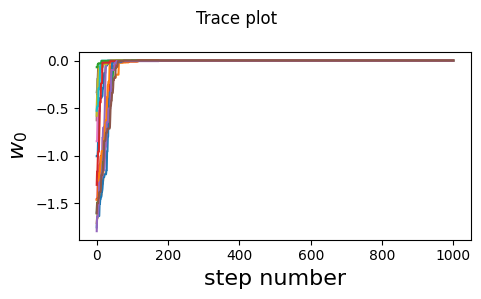

In [18]:
from matplotlib import pyplot as plt
fig, axs = plt.subplots(ndim, 1, figsize=(5,ndim*3))
fig.suptitle('Trace plot')
axs=axs if ndim > 1 else [axs]
for i in range(ndim):
    print(i)
    axs[i].set_ylabel(labels[i], fontsize=16)
    axs[i].set_xlabel('step number', fontsize=16)
    for j in range(nwalkers):
        axs[i].plot(samples[j,:,i], c=f'C{j}')
plt.tight_layout()
plt.show()

In [ ]:
print(flat_samples.shape)

(16, 1000, 4)


In [ ]:
AstronomyCalc.plot_posterior_corner(
    flat_samples,
    labels,
    truths=param_true
)

(16, 1000, 4)


AssertionError: The input sample array must be 1- or 2-D.